In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm import tqdm
import os

In [2]:
root = "."

# data_pockets = pd.read_csv(os.path.join(root, "..", ""))
PATH_TO_RESULTS = "/aloy/home/acomajuncosa/Ersilia/gcadda4tb-enamine-real-screening/results"
CHUNKS = pd.read_csv("/aloy/home/acomajuncosa/Ersilia/gcadda4tb-enamine-real-screening/data/chunks/chunks.csv", header=None)[0].tolist()

POCKETS = sorted(set(sorted([i.split("_ind_")[0] for i in sorted(os.listdir(os.path.join(PATH_TO_RESULTS, "Enamine_REAL_LeadLike_000")))])))

In [3]:
perc = "1"

In [4]:
# For each chunk
for chunk in CHUNKS:

    TOPs = {}

    # For each pocket
    for pocket in tqdm(POCKETS):

        # Get indices at specified percentile
        inds = np.load(os.path.join(PATH_TO_RESULTS, chunk, f"{pocket}_ind_{perc}.npz"))[f"ind_{perc}"]
        cut = float(np.load(os.path.join(PATH_TO_RESULTS, chunk, f"{pocket}_ind_{perc}.npz"))["thr"])

        # Store indices
        TOPs[pocket] = set(inds.tolist())

    break

  0%|          | 0/276 [00:00<?, ?it/s]

100%|██████████| 276/276 [01:27<00:00,  3.16it/s]


In [23]:
SHARED_HITS = []

for c1, pocket1 in tqdm(enumerate(sorted(TOPs))):
    for pocket2 in sorted(TOPs)[c1+1:]:
        intersection = len(TOPs[pocket1].intersection(TOPs[pocket2]))
        SHARED_HITS.append(intersection)

276it [02:19,  1.98it/s]


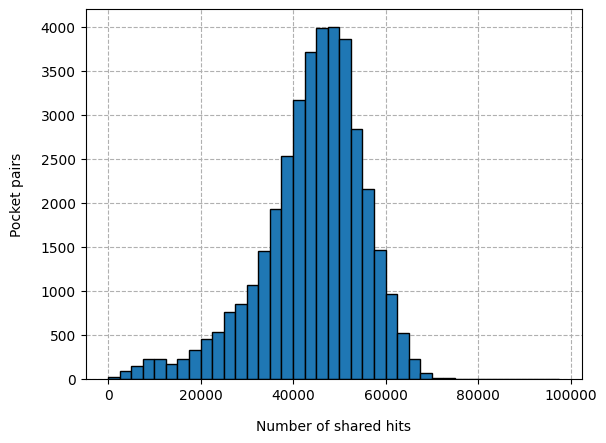

In [35]:
plt.hist(SHARED_HITS, bins=[i for i in range(0, 100_000, 2_500)], edgecolor='k', zorder=2, linewidth=1)
plt.grid(linestyle='--', zorder=-2)
plt.ylabel("Pocket pairs", labelpad=12)
plt.xlabel("Number of shared hits", labelpad=12)
plt.show()

In [41]:
from collections import Counter
counting_cpds = Counter([ind for pocket in sorted(TOPs) for ind in TOPs[pocket]])

In [54]:
len([i for i in counting_cpds if counting_cpds[i] > 200])

27405